## 16. 선형 회귀와 경사 하강법의 학습 방법

#### 경사하강법
-> 모델의 최적화된 방법을 찾도록 도움을 주는 것, 기울기(가중치)와 절편을 이용해 최적화된 모델을 찾아 주는것 => 경사하강법 + 선형회귀

SGD(Stochastic Gradient Descent)가 가중치와 절편을 이용해 오차(절대값, 제곱의 제곱근)를 줄여 정답에 가까워 진다 = MAE, RMSE 방법 사용</br>
-> 경사 하강법을 사용하지 않는다면 모든 경우의 수를 전부 고려해야 한다.

#### 선형회귀식의 가중치(W) 와 절편(bias) => Y = Wx + b
ML / DL 의 학습이란?</br>
-> 데이터를 계속 업데이트(주어진 DataSet 의 데이터값들을 순차적으로 적용) 하면서 오차(Y - Y^)가 가장 적은 기준값의 가중치와 절편을 찾는 것.

- 규칙 이란? 가중치와 절편을 계속 업데이트 하는 것
- 규제 란? 과대적합(Train Data에 대한 정확도는 높으나, Test Data에 대한 정확도는 낮은 현상)을 방지하기 위해 가중치와 절편을 줄이는 방법</br>
    Ex.) y = A1x1 + A2x2 + A3x3 + ... > 해당 식에서 A 값에 0 을 대입하는 방식으로 가중치 또는 절편을 줄일 수 있다.

#### 당뇨병 환자 데이터

In [2]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()

In [3]:
# 데이터의 크기 확인
print(diabetes.data.shape) # Feature
print(diabetes.target.shape) # Target

(442, 10)
(442,)


In [7]:
diabetes.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [8]:
# data의 일부보기(0~2번 Sample)
diabetes.data[0:2+1]

array([[ 0.03807591,  0.05068012,  0.06169621,  0.02187239, -0.0442235 ,
        -0.03482076, -0.04340085, -0.00259226,  0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, -0.02632753, -0.00844872,
        -0.01916334,  0.07441156, -0.03949338, -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, -0.00567042, -0.04559945,
        -0.03419447, -0.03235593, -0.00259226,  0.00286131, -0.02593034]])

In [9]:
# Target의 일부 보기(0~2번 Sample)
diabetes.target[:2+1]

array([151.,  75., 141.])

#### 당뇨병 환자 데이터의 시각화

In [10]:
import matplotlib.pyplot as plt

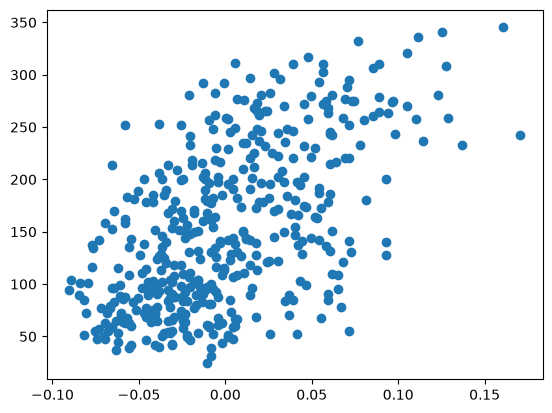

In [12]:
plt.scatter(
    diabetes.data[:,2],
    diabetes.target
)
plt.show()

In [15]:
# 상관계수 알아보기
# 0 3 5 7 -> 30% 까지는 상관없는 데이터, 4-60% 연관성이 보이는 데이터, 70% 이상은 연관있는 데이터
# 공선성 위반 Keyword 참고
import numpy as np

In [16]:
np.corrcoef(diabetes.data[:, 2], diabetes.target)

array([[1.        , 0.58645013],
       [0.58645013, 1.        ]])

----
#### 경사하강법
: 경사하강법은 모델이 데이터를 잘 표현할 수 있도록 기울기(변화율)를 사용하여 모델을 조금씩 조정하는 최적화 알고리즘

##### 예측값과 변화율
변화율 = 0 : 최적화된 모델(Y - Y^ = 0) 즉, 정답값을 찾은 상태

##### 예측값(Y^)
예측값이란, 하나의 모델에서 수식의 결과로 나온 값을 의미한다</br>
-> 예측값이 정답값으로 수렴해야 한다.

#### 훈련데이터에서 잘 맞는 W 와 b 를 찾는 방법 (Y = Wx + b)
1. 무작위로 W와 b를 정한다.
2. x에서 샘플 하나를 선택하여 Y^을 계산한다.
3. Y^ 과 선택한 샘플의 진짜 Y를 비교한다. -> 예측값과 정답 구하기 = 오차 구하기
4. Y^ 이 Y와 가까워지도록 W,b 를 조정한다. -> 모델 조정하기 = 학습하기
5. 모든 샘플을 처리할 때 까지 2~4 항목을 반복한다.

In [30]:
# 훈련데이터의 Feature와 Target 정하기
x = diabetes.data[:, 2]
y = diabetes.target

print(x[:5])
print(y[:5])

[ 0.06169621 -0.05147406  0.04445121 -0.01159501 -0.03638469]
[151.  75. 141. 206. 135.]


In [31]:
# W와 b 무작위로 초기화 하기
w = 1
b = 1

In [32]:
# 훈련데이터의 첫번째 샘플로 Y^ 계산하기
y_hat = x[0] * w + b
y_hat

np.float64(1.0616962065186832)

In [33]:
# Target 과 예측데이터 비교
print(y_hat)
print(y[0])

1.0616962065186832
151.0


> Target 과 예측값 간의 차이가 크다

In [34]:
# W와 b를 조금씩 변경해서 y_hat의 증/감 확인
# 기존 W 값 0.1 만 증가
w_inc = w + 0.1
y_hat_inc = w_inc * x[0] + b
y_hat_inc

np.float64(1.0678658271705517)

> y_hat 보다 y_hat_inc 가 조금 더 Target에 근접함

In [35]:
# W값을 조정한 후, 예측값 정도 확인하기
# W가 0.1 증가했을 때, y_hat 이 얼마나 증가했는지 계산해보기 = 변화율 확인
w_rate = (y_hat_inc - y_hat) / (w_inc - w)
w_rate

np.float64(0.06169620651868429)

In [36]:
# 0.1 -> 0.2
w_inc = w + 0.2
y_hat_inc = w_inc * x[0] + b
w_rate = (y_hat_inc - y_hat) / (w_inc - w)
w_rate

np.float64(0.06169620651868325)

> w_rate(변화율) = x[0]

In [38]:
# 변화율을 확인했으니 다시 훈련데이터의 1번값으로 변화율을 구해보자
w = b = 1
y_hat = x[0] * w + b
w_inc = w + 0.1
y_hat_inc = w_inc * x[0] + b
w_rate = (y_hat_inc - y_hat) / (w_inc - w)
print(w_rate)

0.06169620651868429


In [39]:
# 변화율로 가중치 업데이트 -> 학습하기
w_new = w + w_rate
w_new

np.float64(1.0616962065186843)

In [40]:
# 변화율로 절편 업데이트 -> 학습하기
b_inc = b + 0.1
y_hat_inc = w * x[0] + b_inc
y_hat_inc

np.float64(1.1616962065186833)

In [41]:
b_rate = (y_hat_inc - y_hat) / (b_inc - b)
b_rate

np.float64(1.0)

In [42]:
b_new = b + 1
b_new

2

#### 오차 역전파(Backpropagation)
- 오차 역전파로 가중치와 절편 업데이트 -> 손실함수(비용함수)를 구성한다.
- 오차 역전파는 Y^ 고 Y의 차이를 이용하여 W와 b를 업데이트
- 오차와 변화율을 곱하여 가중치 업데이트

In [43]:
err = y[0] - y_hat
w_new = w + w_rate * err
b_new = b + b_rate * err
print(w_new, b_new)

10.250624555903848 150.9383037934813


In [45]:
# 2번째 샘플 x[1]을 사용하여 오차를 구하고 새로운 W와 b를 구하기
y_hat = w_new * x[1] + b_new
err = y[1] - y_hat
w_rate = x[1]
w_new = w_new + w_rate * err
b_new = b_new + 1 * err
print(w_new, b_new)

14.132317616380695 75.52764127612656


----

In [46]:
# 반복문을 통한 전체 샘플을 반복하기
w = b = 1
for x_i, y_i in zip(x, y):
    y_hat = x_i * w + b
    err = y_i - y_hat
    w_rate = x_i
    w = w + w_rate * err
    b = b + 1 * err

print(w, b)

587.8654539985616 99.4093556453094


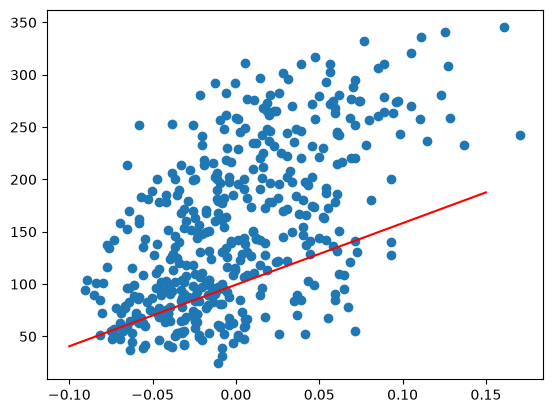

In [49]:
# 그래프로 확인
plt.scatter(x, y)
pt1 = (-0.1, -0.1 * w + b)
pt2 = (0.15, 0.15 * w + b)
plt.plot(
    [pt1[0], pt2[0]],
    [pt1[1], pt2[1]],
    c = 'r'
)

plt.show()

#### Epoch로 반복하기 -> KeyWord : Epoch

In [50]:
# Epoch를 통한 반복하기
w = b = 1
for _ in range(300):
    for x_i, y_i in zip(x, y):
        y_hat = x_i * w + b
        err = y_i - y_hat
        w_rate = x_i
        w = w + w_rate * err
        b = b + 1 * err

print(w, b)

913.5973364346786 123.39414383177173


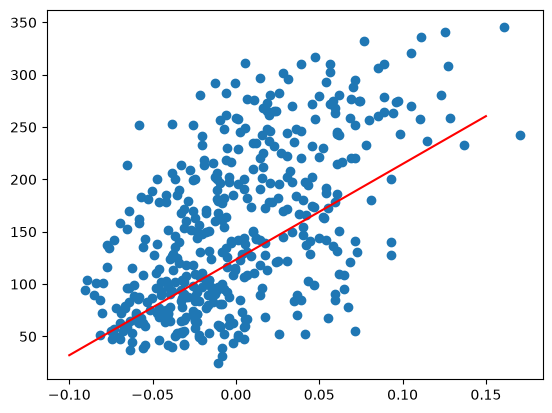

In [51]:
# 그래프로 확인
plt.scatter(x, y)
pt1 = (-0.1, -0.1 * w + b)
pt2 = (0.15, 0.15 * w + b)
plt.plot(
    [pt1[0], pt2[0]],
    [pt1[1], pt2[1]],
    c = 'r'
)

plt.show()

> Y^ = 913.6 * X + 123.4

In [54]:
# 모델로 예측해 보기
x_new = 0.18
y_pred = x_new * w + b
y_pred

np.float64(287.8416643900139)

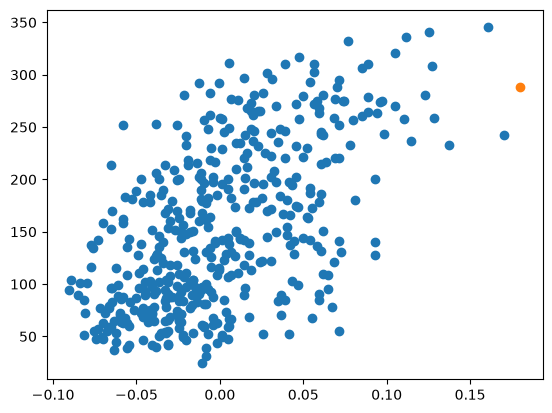

In [56]:
plt.scatter(x, y)

plt.scatter(x_new, y_pred)

plt.show()